In [1]:
!pip install numpy seaborn matplotlib pandas

# LAB 2: DATA VISUALIZATION IN PYTHON
**Course:** Data Visualisation  
**Instructor:** Vo Nhat Tan  

### Team Members:
1. [Name 1] - [Student ID 1]
2. [Name 2] - [Student ID 2]
3. [Name 3] - [Student ID 3]
4. [Name 4] - [Student ID 4]

---

### Introduction & Lab Objectives

**Lab Purpose:** 
This notebook processes and visualizes data from the **World Bank's World Development Indicators (WDI)**. Through 15 specific visualization objectives using Python, the goal is to uncover changing trends in macroeconomics, energy shifts, and human development across the Asia-Pacific region.

**Tools & Libraries:** 
* **`pandas`** for time-series data wrangling and missing value handling.
* **`matplotlib`** & **`seaborn`** for rendering analytical charts.
* **`scikit-learn`** & **`numpy`** for scaling data (e.g., Radar charts) and complex multi-dimensional calculations.

## 1. Basic Data Analysis

### 1.1. Dataset Introduction
This dataset uses the **World Development Indicators (WDI)** collected from the World Bank. 

**Dataset Scope:**
* **Timeframe:** 15 consecutive years from **2008 to 2022**.
* **Geography:** 16 countries located in the Asia-Pacific and ASEAN regions (e.g., Viet Nam, Japan, Australia, China, Singapore).
* **Indicators:** 13 variables divided carefully into 5 main groups. Below is the detailed breakdown of the fields we will be analyzing:

**1. Macroeconomy:**
*   **GDP growth:** The annual percentage growth rate of GDP at market prices. *(Unit: %)*
*   **Inflation, consumer prices:** The annual percentage change in the cost to the average consumer. *(Unit: %)*
*   **Unemployment, total:** The share of the labor force that is without work but available for and seeking employment. *(Unit: % of total labor force)*

**2. Energy Transition:**
*   **Electricity production from oil, gas and coal sources:** Showcases the reliance on fossil fuels for electricity. *(Unit: % of total electricity)*
*   **Electricity production from renewable sources, excluding hydroelectric:** Shows the shift towards green energy types like solar and wind. *(Unit: % of total electricity)*

**3. Environment:**
*   **Carbon dioxide (CO2) emissions (excluding LULUCF):** Total CO2 gas emissions. *(Unit: Mt CO2e - Mega tonnes)*
*   **Methane (CH4) emissions (excluding LULUCF):** Total CH4 gas emissions. *(Unit: % change from 1990)*

**4. Human Development & Infrastructure:**
*   **Life expectancy at birth, total:** How many years a newborn is expected to live. *(Unit: years)*
*   **School enrollment, tertiary:** The ratio of students enrolled in universities/colleges. *(Unit: % gross)*
*   **Government expenditure on education, total:** How much a country's government spends on education. *(Unit: % of GDP)*
*   **Access to electricity, rural:** The percentage of rural population with electricity. *(Unit: % of rural population)*
*   **People using at least basic drinking water services:** The percentage of people with safe water. *(Unit: % of population)*

**5. Demographic:**
*   **Population, total:** Total count of all residents. *(Unit: People)*

**Initial Inspection:**
* The raw `data.csv` file has **213 rows** and **19 columns**. 
* The first 4 columns contain IDs (Country Name, Country Code, Series Name, Series Code), and the next 15 columns cover the yearly data.
* The final 5 rows are empty metadata left over from the World Bank export.

First, we load the raw dataset to inspect its dimensions, data types, and identify any structural anomalies.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Data & Overview
df = pd.read_csv('WDI/data.csv')
print("Size:", df.shape)

df.info()

display(df.head())
display(df.tail())

Size: (213, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country Name   210 non-null    object
 1   Country Code   208 non-null    object
 2   Series Name    208 non-null    object
 3   Series Code    208 non-null    object
 4   2008 [YR2008]  208 non-null    object
 5   2009 [YR2009]  208 non-null    object
 6   2010 [YR2010]  208 non-null    object
 7   2011 [YR2011]  208 non-null    object
 8   2012 [YR2012]  208 non-null    object
 9   2013 [YR2013]  208 non-null    object
 10  2014 [YR2014]  208 non-null    object
 11  2015 [YR2015]  208 non-null    object
 12  2016 [YR2016]  208 non-null    object
 13  2017 [YR2017]  208 non-null    object
 14  2018 [YR2018]  208 non-null    object
 15  2019 [YR2019]  208 non-null    object
 16  2020 [YR2020]  208 non-null    object
 17  2021 [YR2021]  208 non-null    object
 18  2022 [YR2022] 

,Country Name,Country Code,Series Name,Series Code,2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022]
0,Brunei Darussalam,BRN,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,..,..,1.84384000301361,3.32213997840881,2.88964009284973,..,3.35321998596191,..,4.42539978027344,..,..,..,..,..,..
1,Brunei Darussalam,BRN,"School enrollment, tertiary (% gross)",SE.TER.ENRR,15.7385101318359,16.5658493041992,15.3331563578444,17.4270912772504,22.0733483384086,23.4649239797279,30.0799102783203,28.6641292572021,28.6644096374512,31.2433910195239,27.9285989469629,27.7715019255456,29.1961193084717,27.4258937503291,31.1925368707703
2,Brunei Darussalam,BRN,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,..,..,..,..,..,..,6.862,..,..,9.316,8.7,6.6,7.409,4.905,5.191
3,Brunei Darussalam,BRN,"Electricity production from oil, gas and coal ...",EG.ELC.FOSL.ZS,100,100,100,99.9463087248322,99.9491094147583,99.9545661063153,99.9556147359077,99.9523809523809,99.9765807962529,99.951888381044,99.9534125320289,99.9594484995945,99.947689625109,99.9122653097035,99.875044626919
4,Brunei Darussalam,BRN,"Electricity production from renewable sources,...",EG.ELC.RNWX.ZS,0,0,0.0213607594936709,0.043489932885906,0.0424936386768448,0.038391640163562,0.0359520639147803,0.0311904761904762,0.0255269320843091,0.0377676208804426,0.037037037037037,0.0218978102189781,0.0193548387096774,0.0196525706264257,..


,Country Name,Country Code,Series Name,Series Code,2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022]
208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
211,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
212,Last Updated: 02/24/2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


From the `df.info()` output and data preview, we found a few data quality issues:
1. **Footer rows:** The last 5 rows are export metadata with no actual data, which can interfere with filtering or calculations.
2. **Missing placeholders:** Missing values are marked as `..` instead of the standard `NaN`.
3. **Data types:** Because of the `..` text, pandas reads the year columns (`[YR2008]`, etc.) as text (`object`) instead of numbers (`float`). 
4. **Wide format:** The years are spread out as separate columns. This "wide" structure makes it difficult to plot grouped charts later.

**=> Cleaning Plan:** To fix this, we will drop the last 5 rows, clean the column names, replace `..` with `NaN`, set the correct numeric data type, and use `melt` to restructure the data into a "long format".

### 1.2. Data Cleaning and Reshaping
The data is transformed in 3 steps:
1. **Filtering:** Remove the 5 footer rows and drop redundant identifier columns (`Series Code`, `Country Code`).
2. **Standardization:** Convert `2008 [YR2008]` style headers into plain years (`2008`), replace `..` with `NaN`, and cast all year values to numeric types.
3. **Reshaping (Melt):** Convert from wide format (one column per year) into a long format with fields: `Country Name`, `Series Name`, `Year`, `Value`. This format is essential for visualizations in Seaborn/Matplotlib.

We will remove footers, handle placeholders, standardize column names, and reshape the dataset for visualization.

In [3]:
# Drop metadata footers
df_clean = df.dropna(subset=['Country Code']).copy()
df_clean = df_clean.drop(['Series Code', 'Country Code'], axis=1)

# Rename year columns ('2008 [YR2008]' -> '2008')
df_clean = df_clean.rename(columns={col: col.split(' ')[0] for col in df_clean.columns if '[YR' in col})

# Handle placeholders and cast to float
year_cols = sorted([col for col in df_clean.columns if col.isdigit()], key=int)
df_clean[year_cols] = df_clean[year_cols].replace('..', np.nan)
df_clean[year_cols] = df_clean[year_cols].astype(float)

# Melt to Long Format for visualization later
id_vars = ['Country Name', 'Series Name']
df_melted = pd.melt(df_clean, id_vars=id_vars, value_vars=year_cols, var_name='Year', value_name='Value')
df_melted['Year'] = df_melted['Year'].astype(int)

print(f"Rows (long format): {df_melted.shape[0]}")
print(f"Countries: {df_melted['Country Name'].nunique()} | Variables: {df_melted['Series Name'].nunique()}")
print(f"Year range: {df_melted['Year'].min()}-{df_melted['Year'].max()} ({len(year_cols)} years)")

print("\n--- CLEANED DATA TYPES ---")
print(df_melted.dtypes)

Rows (long format): 3120
Countries: 16 | Variables: 13
Year range: 2008-2022 (15 years)

--- CLEANED DATA TYPES ---
Country Name     object
Series Name      object
Year              int64
Value           float64
dtype: object


* The dataset is completely transformed into **3,120 long records** (**16 countries x 13 indicators x 15 years**).
* The structure now safely contains 4 standardized fields: `Country Name`, `Series Name`, `Year`, and `Value`. 
* **Data Types:** `Year` is successfully cast to `int64` and the measurement `Value` is recognized as `float64`.

### 1.3. Missing Value Evaluation
Before determining an imputation strategy, we check the missing value counts across Series, Year, and Country.

In [4]:
# Missing Value Evaluation
missing_counts = df_melted[df_melted['Value'].isnull()].groupby('Series Name').size()
total_counts = df_melted.groupby('Series Name').size()

missing_stats = pd.DataFrame({
    'Missing': missing_counts,
    'Expected': total_counts,
    'Missing (%)': (missing_counts / total_counts) * 100
}).fillna(0).sort_values(by='Missing (%)', ascending=False)
display(missing_stats)

print("\n--- MISSING BY YEAR ---")
print(df_melted[df_melted['Value'].isnull()].groupby('Year').size())

print("\n--- MISSING BY COUNTRY  ---")
print(df_melted[df_melted['Value'].isnull()].groupby('Country Name').size().sort_values(ascending=False).head())

,Missing,Expected,Missing (%)
Series Name,,,
"Government expenditure on education, total (% of GDP)",71.0,240,29.583333
"School enrollment, tertiary (% gross)",53.0,240,22.083333
"Unemployment, total (% of total labor force) (national estimate)",44.0,240,18.333333
"Electricity production from renewable sources, excluding hydroelectric (% of total)",16.0,240,6.666667
"Inflation, consumer prices (annual %)",3.0,240,1.250000
"Electricity production from oil, gas and coal sources (% of total)",1.0,240,0.416667
GDP growth (annual %),0.0,240,0.000000
"Access to electricity, rural (% of rural population)",0.0,240,0.000000
Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),0.0,240,0.000000



--- MISSING BY YEAR ---
Year
2008    18
2009    16
2010    12
2011    13
2012    15
2013    14
2014    11
2015    10
2016    11
2017     7
2018     9
2019     7
2020     9
2021     8
2022    28
dtype: int64

--- MISSING BY COUNTRY  ---
Country Name
Myanmar              36
Timor-Leste          25
Australia            20
Brunei Darussalam    19
China                19
dtype: int64


**Missing Value Evaluation:**
In total, there are **188 missing records**.

* **By Series:** Missing data is highest in *Government expenditure on education* (71), *Tertiary enrollment* (53), and *Unemployment* (44). Public spending and labor data seem harder to track consistently.
* **By Year:** **2022** has the most missing data (28 records). Recent data updates often take time to be published by the World Bank.
* **By Country:** 
  * Developing nations like **Myanmar** (36) and **Timor-Leste** (25) lack data mainly due to limited statistical systems or national instability.
  * Developed nations like **Australia** (20) also miss data, but mostly in education metrics. This means their internal reporting standards don't match the World Bank's definitions.

### 1.4. Handling Missing Data 
**Method:** Linear Interpolation (`method='linear'`). Filling missing values with an overall mean or carrying the last value forward would create flat, unnatural lines in our charts. Linear interpolation connects the dots between two known years to keep the trend smooth.

  We used `limit=4` and `limit_area='inside'`.
  * It only fills small internal gaps (up to 4 consecutive years).
  * It **does not** guess data at the edges. If a country has no data for 2022 at the end of the line, it correctly stays as `NaN`.

In [5]:
# Sort the melted DataFrame for interpolation
df_melted = df_melted.sort_values(by=['Country Name', 'Series Name', 'Year'])
df_processed = df_melted.reset_index(drop=True).copy()

# Interpolate max 4 consecutive years, inside existing data points (some countries have long time reporting gaps)
df_processed['Value'] = df_processed.groupby(['Country Name', 'Series Name'])['Value'].transform(
    lambda x: x.interpolate(method='linear', limit=4, limit_area='inside')
)

print("Total missing values before interpolation:", df_melted['Value'].isnull().sum())
print("Total missing values after interpolation:", df_processed['Value'].isnull().sum())

Total missing values before interpolation: 188
Total missing values after interpolation: 138


**Result:** Missing records were safely reduced from **188 to 138**. We filled exactly **50 internal gaps** between years but kept the endpoint gaps honest.

### 1.5. Descriptive Statistics
With the dataset cleaned and interpolated, we pivot to compute descriptive statistics (count, mean, min, max, standard deviation) across all **13 indicators**.

In [6]:
pivot_df = df_processed.pivot_table(index=['Country Name', 'Year'], 
                                    columns='Series Name', values='Value').reset_index()

print("STATISTICS")
display(pivot_df.describe().T[['count', 'mean', 'min', 'max', 'std']])

STATISTICS


,count,mean,min,max,std
Series Name,,,,,
Year,240.0,2.015000e+03,2008.000000,2.022000e+03,4.329523e+00
"Access to electricity, rural (% of rural population)",240.0,8.840792e+01,11.700000,1.000000e+02,2.104462e+01
Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),240.0,9.004619e+02,0.310900,1.255186e+04,2.568095e+03
"Electricity production from oil, gas and coal sources (% of total)",239.0,7.058465e+01,0.000000,1.000000e+02,2.644896e+01
"Electricity production from renewable sources, excluding hydroelectric (% of total)",224.0,6.247243e+00,-9.996215,2.711663e+01,7.131819e+00
GDP growth (annual %),240.0,4.084775e+00,-20.522479,3.172574e+01,4.597826e+00
"Government expenditure on education, total (% of GDP)",183.0,3.583144e+00,0.787440,1.290248e+01,1.823713e+00
"Inflation, consumer prices (annual %)",237.0,3.227385e+00,-1.610680,2.679954e+01,3.903966e+00
"Life expectancy at birth, total (years)",240.0,7.450206e+01,56.364000,8.456000e+01,6.552374e+00


**Descriptive Statistics Findings:**
With the data cleaned and gap-filled, we computed count, mean, min, max, and std:

1. **Different Scales:** The indicators have widely different ranges. For example, *GDP growth* is usually single digits (mean ~4.1%), but *Population* scales up to 1.41 billion. So when plotting, we need to use separate charts, dual-axes, or normalize the data.
2. **Economic Volatility:** Economic markers are unstable. *GDP growth* ranges from a -20.5% drop to a 31.7% surge. *Inflation* also fluctuates from -1.6% to 26.8%.
3. **Huge Infrastructure Gaps:** Developed countries usually have 100% access, but developing countries drag the minimums down. *Rural electricity access* drops to 11.7%, and *Basic drinking water access* is 59.7% at its worst.
4. **Total vs. Per Capita Bias:** Absolute amounts like *Total CO2 Emissions* vary hugely (from 0.31 Mt to 12,551.8 Mt) just because of country size. We will need to look at per-capita metrics to compare efficiency fairly.

### Summary
Our pre-processing is complete, and the data is ready for visualization:
1. **Clean Structure:** Tidy long-format dataset of **3,120 rows** (`Country Name`, `Series Name`, `Year`, `Value`), covering 16 countries and 13 indicators over 15 years.
2. **Missing Data:** Interpolation filled 50 short gaps, leaving exactly **138 missing records** at the edges.
3. **Plotting Strategy:** Variables like Population and percentages exist on different scales, we must be careful to use separate charts or dual-axes.

## 2. Objectives and Feature Selection (Task 2)

This section outlines 15 analytical objectives across 5 socio-economic themes. For each objective, we specify the target metrics, their rationale, and the chosen visualization technique focusing on data properties.

### Theme 1: Macroeconomic Trends and Volatility

**Objective 1: Track GDP growth over time (2008-2022)**
* **Metric:** GDP growth (annual %).
* **Meaning:** Year-over-year economic growth rate.
* **Rationale:** Standard indicator to measure continuous economic expansion or contraction.
* **Chart choice:** Line chart. Ideal for showing continuous trends over time for time-series data.

**Objective 2: Examine the inflation-unemployment relationship (Phillips Curve)**
* **Metrics:** Inflation (annual %) & Unemployment (% of labor force).
* **Meaning:** Measures price increases against job shortages.
* **Rationale:** Tests the Phillips Curve theory (the inverse relationship between inflation and unemployment).
* **Chart choice:** Scatter plot with trendline. Perfect for showing the correlation between two numerical variables.

**Objective 3: Compare GDP growth stability and distribution shape**
* **Metric:** GDP growth (annual %).
* **Meaning:** Frequency and concentration of different growth rates.
* **Rationale:** Evaluates economic volatility over 15 years, moving beyond just average performance.
* **Chart choice:** KDE (Kernel Density Estimation) plot. Excellent for visualizing the distribution and density of a continuous numerical variable.

---

### Theme 2: Energy Transition and Environmental Impact

**Objective 4: Assess the shift from fossil to renewable electricity**
* **Metrics:** Electricity from fossil fuels (%) & from renewables (%).
* **Meaning:** Percentage breakdown of electricity sources.
* **Rationale:** Directly tracks a country's transition toward clean energy.
* **Chart choice:** Stacked area chart. Best for showing both the part-to-whole relationship (composition) and how it evolves over continuous time.

**Objective 5: Evaluate progress in Methane (CH4) emission mitigation**
* **Metric:** Methane emissions (% change from 1990).
* **Meaning:** Relative change in methane emissions compared to the 1990 baseline.
* **Rationale:** Percentage change enables fair comparisons regardless of country size.
* **Chart choice:** Horizontal bar chart. Most effective for ranking categorical data measured against a single numerical value.

**Objective 6: Track CO2 emissions trend and efficiency (2008-2022)**
* **Metrics:** Total CO2 emissions (Mt CO2e) & CO2 per capita (Tonnes).
* **Meaning:** Overall emission scale vs. individual carbon footprint.
* **Rationale:** Contrasts total national impact with per-person environmental efficiency.
* **Chart choice:** Two side-by-side line charts. Useful for side-by-side comparisons of time-series data at different scales (absolute vs. normalized per capita ratios).

---

### Theme 3: Human Capital and Educational Investment

**Objective 7: Evaluate government priority for education**
* **Metric:** Government expenditure on education (% of GDP).
* **Meaning:** Share of national wealth invested in public education.
* **Rationale:** Standardizes spending by economic size to fairly compare policy priorities.
* **Chart choice:** Horizontal bar chart. Most effective for ranking categorical data (countries) based on a single numerical value.

**Objective 8: Examine education investment vs. tertiary enrollment**
* **Metrics:** Education expenditure (% of GDP) & Tertiary enrollment (% gross).
* **Meaning:** Financial input versus educational outcome.
* **Rationale:** Tests whether higher financial investment correlates with higher university enrollment.
* **Chart choice:** Scatter plot. Effectively maps the linear relationship between financial input (x-axis) and educational output (y-axis) across numerical data points.

**Objective 9: Monitor expansion of tertiary education access**
* **Metric:** Tertiary enrollment (% gross).
* **Meaning:** Percentage of the population attending higher education.
* **Rationale:** Tracks the long-term development of a highly educated workforce.
* **Chart choice:** Line chart. Ideal for comparing multi-year growth trajectories for time-series data across categorical entities (nations).

---

### Theme 4: Infrastructure and Public Health

**Objective 10: Measure progress in rural electrification**
* **Metric:** Access to electricity, rural (% of rural population).
* **Meaning:** Coverage of electricity in rural demographics.
* **Rationale:** A core indicator of infrastructure development and poverty reduction.
* **Chart choice:** Line chart. Highlights infrastructural catch-up progress for continuous time-series data, specifically focusing on developing nations.

**Objective 11: Evaluate water access and life expectancy relationship**
* **Metrics:** Basic drinking water access (%) & Life expectancy at birth (years).
* **Meaning:** Basic public sanitation coverage versus human lifespan.
* **Rationale:** Verifies the developmental link between basic infrastructure and health outcomes.
* **Chart choice:** Scatter plot. Clearly reveals clusters and positive correlations between two continuous numerical variables in global public health data.

**Objective 12: Compare the distribution of life expectancy across countries**
* **Metric:** Life expectancy at birth (years).
* **Meaning:** The expected average lifespan.
* **Rationale:** Summarizes overall health quality and highlights the global health gap.
* **Chart choice:** Violin plot. Ideal for comparing the probability distribution and central tendency (median/quartiles) of numerical data across multiple categories.

---

### Theme 5: Multi-Dimensional Synthesis

**Objective 13: Build a cross-indicator correlation overview**
* **Metrics:** All 13 numeric indicators.
* **Meaning:** Pairwise relationships among all variables.
* **Rationale:** Provides a system-level scan for macro-patterns before specific analysis.
* **Chart choice:** Correlation heatmap. Provides a global view of pairwise correlation coefficients across all continuous numerical variables in a single matrix.

**Objective 14: Compare multi-dimensional country profiles**
* **Metrics:** GDP growth, CO2 per capita, Tertiary enrollment, Access to electricity, Life expectancy.
* **Meaning:** A holistic snapshot across economic, environmental, educational, and health pillars.
* **Rationale:** Evaluates a country's overall development balance.
* **Chart choice:** Radar chart (Spider chart). Perfect for synthesizing multi-dimensional numerical data into a profile to compare categorical entities (countries). *(Requires Min-Max scaling to align different units).*

**Objective 15: Explore the modernization trade-off (Quality of Life vs. Emissions)**
* **Metrics:** Life expectancy (Y-axis), CO2 per capita (X-axis), and Population (Bubble size).
* **Meaning:** Health outcomes versus individual carbon cost, contextualized by country size.
* **Rationale:** Examines if living longer necessitates higher emissions, accounting for absolute global scale.
* **Chart choice:** Bubble chart. Extends a scatter plot by visualizing three numerical variables simultaneously (x, y, and size), enabling complex multi-variate comparisons.

## 3. Visualization and Analysis

### Theme 1: Macroeconomic Trends and Volatility

**Objective 1: Track GDP growth over time (2008-2022)**
*   **Chart Choice:** Line chart. Ideal for showing continuous trends over time for time-series data.
*   **Design Choice:** Plotting 16 countries simultaneously can create a confusing "spaghetti plot". We will highlight a few key economies (e.g., Vietnam, China, Australia, Japan) and fade the rest into the background to make the trends readable.

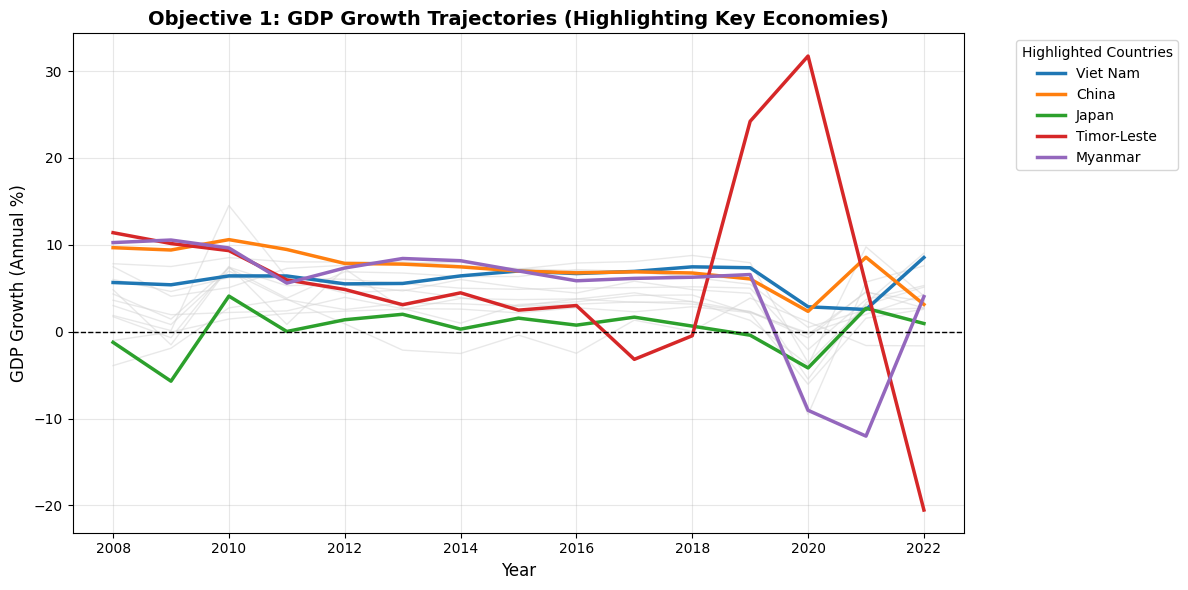

In [7]:
# Objective 1 Code
plt.figure(figsize=(12, 6))

# Define key countries to highlight
# VN, Timor Leste, Myanma, China, Japan
# highlight_countries = ['Viet Nam', 'China', 'Australia', 'Japan', 'Korea', 'New Zealand', 'Timor-Leste', 'Thailand', 'Singapore', 'Philippines', 'Myanmar', 'Malaysia', 'Lao PDR', 'Indonesia', 'Cambodia', 'Brunei Darussalam']
highlight_countries = ['Viet Nam', 'China', 'Japan', 'Timor-Leste', 'Myanmar']
palette = sns.color_palette("tab10", len(highlight_countries))

# Plot background countries (light gray)
for country in pivot_df['Country Name'].unique():
    if country not in highlight_countries:
        country_data = pivot_df[pivot_df['Country Name'] == country]
        sns.lineplot(data=country_data, x='Year', y='GDP growth (annual %)', color='lightgray', alpha=0.5, linewidth=1)

# Plot highlighted countries (colored and bold)
for idx, country in enumerate(highlight_countries):
    country_data = pivot_df[pivot_df['Country Name'] == country]
    sns.lineplot(data=country_data, x='Year', y='GDP growth (annual %)', color=palette[idx], label=country, linewidth=2.5)

# Add horizontal line at 0% for baseline reference
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title('Objective 1: GDP Growth Trajectories (Highlighting Key Economies)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('GDP Growth (Annual %)', fontsize=12)
plt.legend(title='Highlighted Countries', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 1):**
* **General Trend:** Most economies in the dataset grow at 10% or less per year, with occasional years of negative growth (economic contraction). 
* **High Instability (Timor-Leste):** Timor-Leste is the most volatile country on the chart. Its growth dropped from 11% in 2008 to 0% in 2018, spiked to 30% in 2020, and then crashed to -20% in 2022.
* **Stable Growth (Viet Nam):** Viet Nam shows highly stable economic performance, consistently maintaining a growth rate of around 5% to 7% per year before the pandemic.
* **Stagnation (Japan):** Japan displays economic stagnation. Its annual growth rate hovers near 0% and drops into negative numbers multiple times over the 15-year period.
* **Slowing Growth (China):** China's economy is relatively stable but shows a clear, gradual slowdown over time, dropping from about 10% growth in 2008 down to roughly 3-5% by 2022.
* **Sudden Decline (Myanmar):** Myanmar maintained positive growth until 2019. The economy then shrank severely over the next two years (dropping to nearly -12%) before rebounding slightly in 2022.

**Objective 2: Examine the inflation-unemployment relationship (Phillips Curve)**
*   **Chart Choice:** Scatter plot with a regression line. Perfect for showing the correlation between two continuous numerical variables to test economic theories.

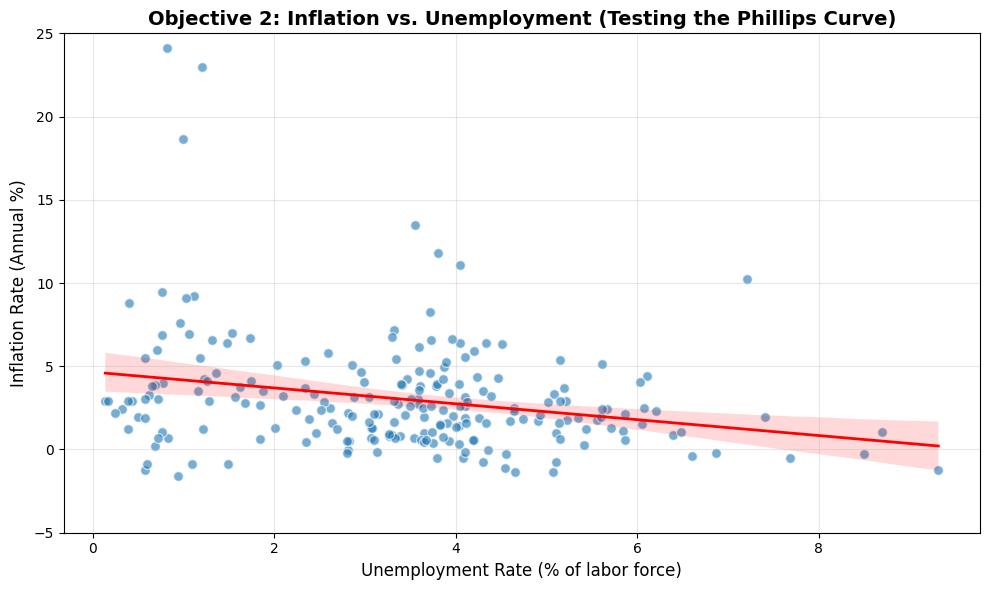

In [8]:
# Objective 2 Code
plt.figure(figsize=(10, 6))

# Scatter plot with regression line to show overall trend
sns.regplot(data=pivot_df, 
            x='Unemployment, total (% of total labor force) (national estimate)', 
            y='Inflation, consumer prices (annual %)', 
            scatter_kws={'alpha': 0.6, 'edgecolor': 'w', 's': 50},
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('Objective 2: Inflation vs. Unemployment (Testing the Phillips Curve)', fontsize=14, fontweight='bold')
plt.xlabel('Unemployment Rate (% of labor force)', fontsize=12)
plt.ylabel('Inflation Rate (Annual %)', fontsize=12)

# Restrict axes slightly to avoid extreme outliers squishing the chart
plt.ylim(-5, 25) 
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 2):**
* **Inverse Relationship:** The graph shows a general inverse relationship, meaning higher inflation correlates with lower unemployment. When unemployment is very low (around 1%), inflation averages near 5%. When unemployment is high (around 8%), inflation drops close to 0%. 
* **Weak Correlation:** Even with a visible trend, this relationship is very weak. The data points are scattered far away from the red trendline. For example, at a 4% unemployment rate, inflation varies drastically across different countries, ranging anywhere from -2% to over 14%.

**Objective 3: Compare GDP growth stability and distribution shape**
*   **Chart Choice:** KDE (Kernel Density Estimation) plot. Excellent for visualizing the distribution and density of a continuous numerical variable. We will overlap the KDE distributions of our key highlighted countries (e.g., Viet Nam, China, Japan, Timor-Leste, Myanmar) to compare their economic stability. A narrow, tall peak indicates a highly stable economy, while a wide, flat distribution highlights volatility.

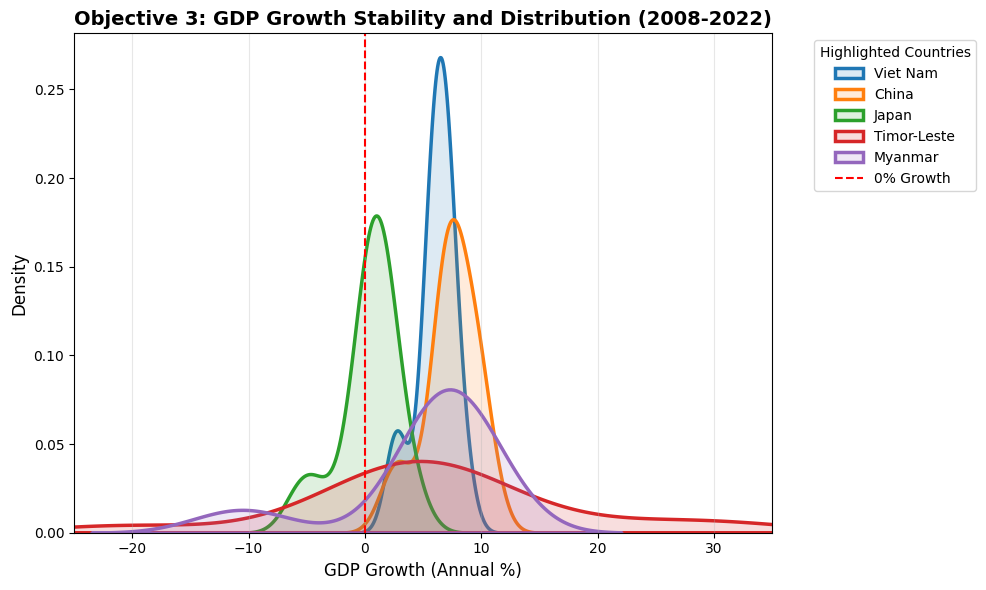

In [9]:
# Objective 3 Code
plt.figure(figsize=(10, 6))

highlight_countries = ['Viet Nam', 'China', 'Japan', 'Timor-Leste', 'Myanmar']
palette = sns.color_palette("tab10", len(highlight_countries))

# Plot Histogram and KDE for highlighted countries
for idx, country in enumerate(highlight_countries):
    country_data = pivot_df[pivot_df['Country Name'] == country]
    sns.kdeplot(data=country_data, x='GDP growth (annual %)', 
                color=palette[idx], label=country, linewidth=2.5, fill=True, alpha=0.15)

plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='0% Growth')

plt.title('Objective 3: GDP Growth Stability and Distribution (2008-2022)', fontsize=14, fontweight='bold')
plt.xlabel('GDP Growth (Annual %)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Highlighted Countries', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', alpha=0.3)
plt.xlim(-25, 35) # Based on previous data limits for readability
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 3):**
* **High Stability (Viet Nam & China):** Viet Nam and China display tall, narrow density peaks between 5% and 7% growth. This narrow distribution confirms sustained, stable economic expansion with minimal volatility.
* **Economic Stagnation (Japan):** Japan's density peak is clustered heavily around 0%, reflecting a prolonged period of extremely low growth.
* **High Volatility (Timor-Leste):** Timor-Leste’s distribution is wide and flat, spanning from -20% to over 30%. This indicates a highly erratic and unstable macroeconomic environment.
* **Negative Skew (Myanmar):** Myanmar shows a primary peak of positive growth but features a secondary distribution bump around -10%, indicating distinct periods of severe economic contraction.

### Theme 2: Energy Transition and Environmental Impact

**Objective 4: Assess the shift from fossil to renewable electricity**
*   **Chart Choice:** Stacked Area Chart (Regional Average). Best for showing both the part-to-whole relationship (composition) and how it evolves over continuous time.

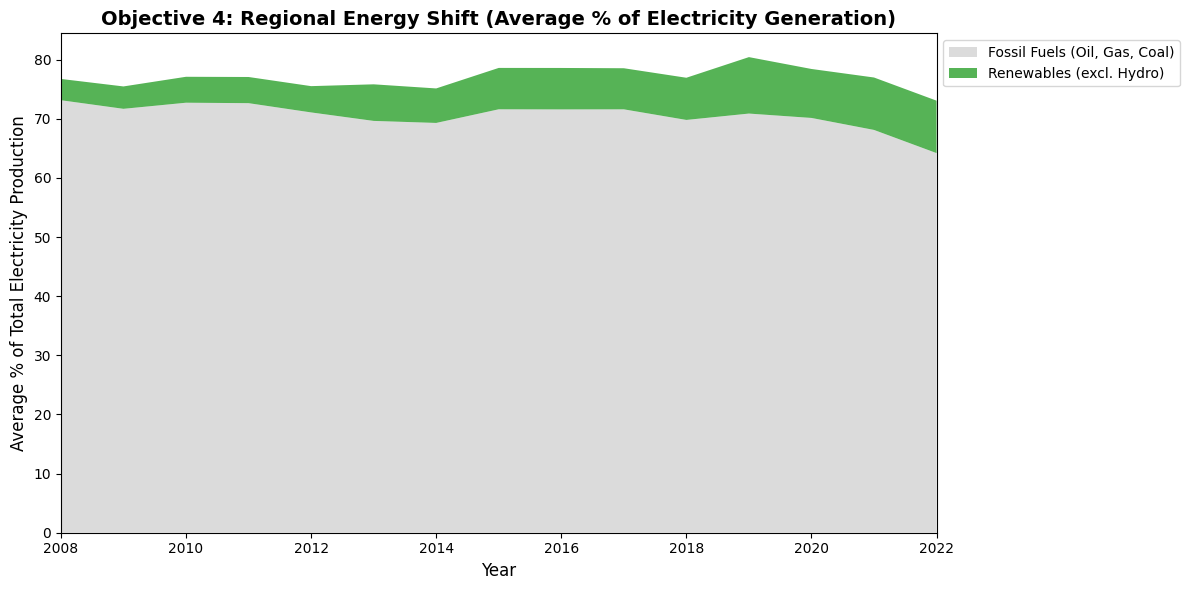

In [10]:
# Objective 4 Code
plt.figure(figsize=(12, 6))

# Calculate regional average per year
energy_trends = pivot_df.groupby('Year')[['Electricity production from oil, gas and coal sources (% of total)', 
                                          'Electricity production from renewable sources, excluding hydroelectric (% of total)']].mean()

# Fill missing values by forward filling (assuming trends continue in the short term)
energy_trends.ffill(inplace=True)

plt.stackplot(energy_trends.index, 
              energy_trends['Electricity production from oil, gas and coal sources (% of total)'], 
              energy_trends['Electricity production from renewable sources, excluding hydroelectric (% of total)'],
              labels=['Fossil Fuels (Oil, Gas, Coal)', 'Renewables (excl. Hydro)'],
              colors=['#d3d3d3', '#2ca02c'], alpha=0.8)

plt.title('Objective 4: Regional Energy Shift (Average % of Electricity Generation)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average % of Total Electricity Production', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.margins(x=0)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 4):**
* **Fossil Fuel Dominance:** Fossil fuels remain the primary electricity source for the region. However, their regional average share decreased significantly from approximately 73% in 2008 to 64% by 2022.
* **Renewable Energy Growth:** The transition to renewable sources (excluding hydroelectric) shows steady and promising progress. Over the 15-year period, its regional average share more, growing from roughly 4% in 2008 to 8% by 2022.

---

**Objective 5: Evaluate progress in Methane (CH4) emission mitigation**
* **Chart Choice:** Horizontal bar chart. Most effective for ranking categorical data measured against a single numerical value. Using red for positive numbers (emission increase) and green for negative numbers (emission decrease) makes the progress instantly clear.

C:\Users\tinti\AppData\Local\Temp\ipykernel_13564\2907701437.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_methane,


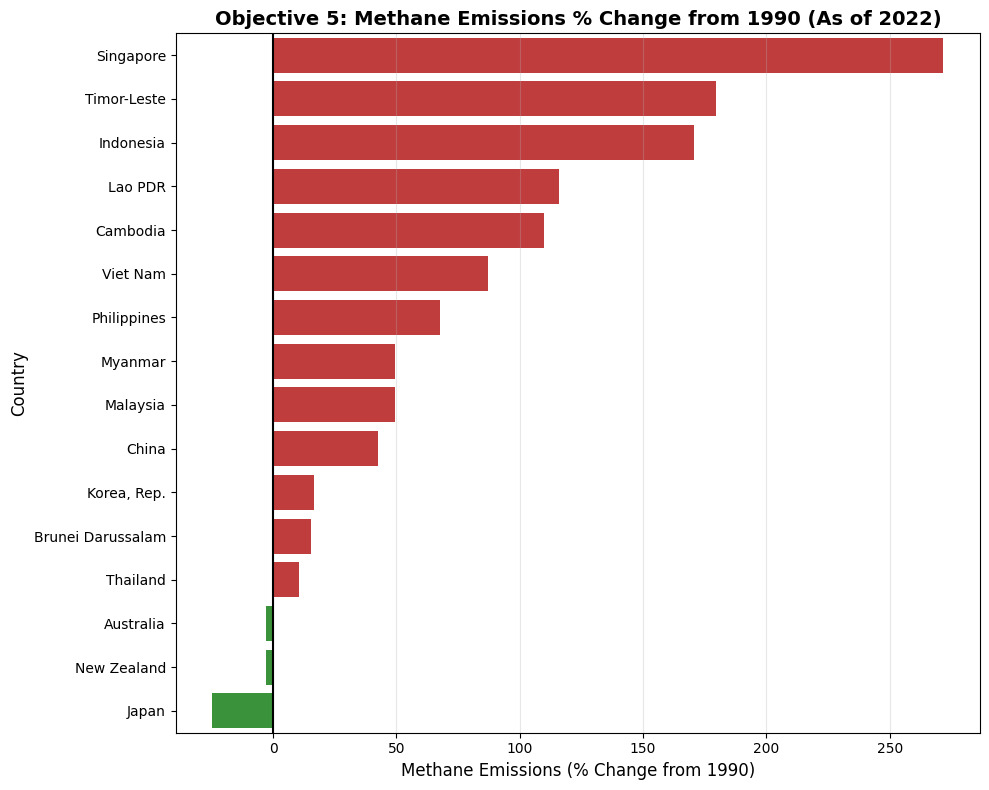

In [11]:
# Objective 5 Code
plt.figure(figsize=(10, 8))

# Filter data for the most recent year (2022) to compare current progress
df_methane = pivot_df[pivot_df['Year'] == 2022].dropna(subset=['Methane (CH4) emissions (total) excluding LULUCF (% change from 1990)'])

# Sort values for a clean bar chart
df_methane = df_methane.sort_values(by='Methane (CH4) emissions (total) excluding LULUCF (% change from 1990)', ascending=False)

# Create a color palette: Red for increase (>0), Green for decrease (<0)
colors = ['#d62728' if x > 0 else '#2ca02c' for x in df_methane['Methane (CH4) emissions (total) excluding LULUCF (% change from 1990)']]

# Plot the horizontal bar chart
sns.barplot(data=df_methane, 
            x='Methane (CH4) emissions (total) excluding LULUCF (% change from 1990)', 
            y='Country Name', 
            palette=colors)

# Add a vertical reference line at 0% (the 1990 baseline)
plt.axvline(0, color='black', linestyle='-', linewidth=1.5)

plt.title('Objective 5: Methane Emissions % Change from 1990 (As of 2022)', fontsize=14, fontweight='bold')
plt.xlabel('Methane Emissions (% Change from 1990)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 5):**
* **Large Increases:** Singapore, Timor-Leste, Indonesia, Lao PDR, and Cambodia show large increases in methane emissions, all growing by over 100% since 1990. Singapore shows the highest increase at nearly 270%.
* **Moderate Growth:** Viet Nam, the Philippines, Myanmar, Malaysia, and China show moderate growth, increasing their methane emissions by roughly 40% to 85% compared to 1990 levels.
* **Reductions:** Only three countries—Japan, Australia, and New Zealand reduced their methane emissions below their 1990 levels.

---

**Objective 6: Track CO2 emissions trend and efficiency (2008-2022)**
* **Chart Choice:** Two side-by-side line charts. Useful for side-by-side comparisons of time-series data at different scales (absolute vs. normalized per capita ratios). The first chart uses a log-scaled Y-axis because the total emissions gap between massive countries (like China) and small ones (like Timor-Leste) is too big for a normal scale. The second chart shows emissions per person on a normal scale, which allows for a fair, direct comparison.

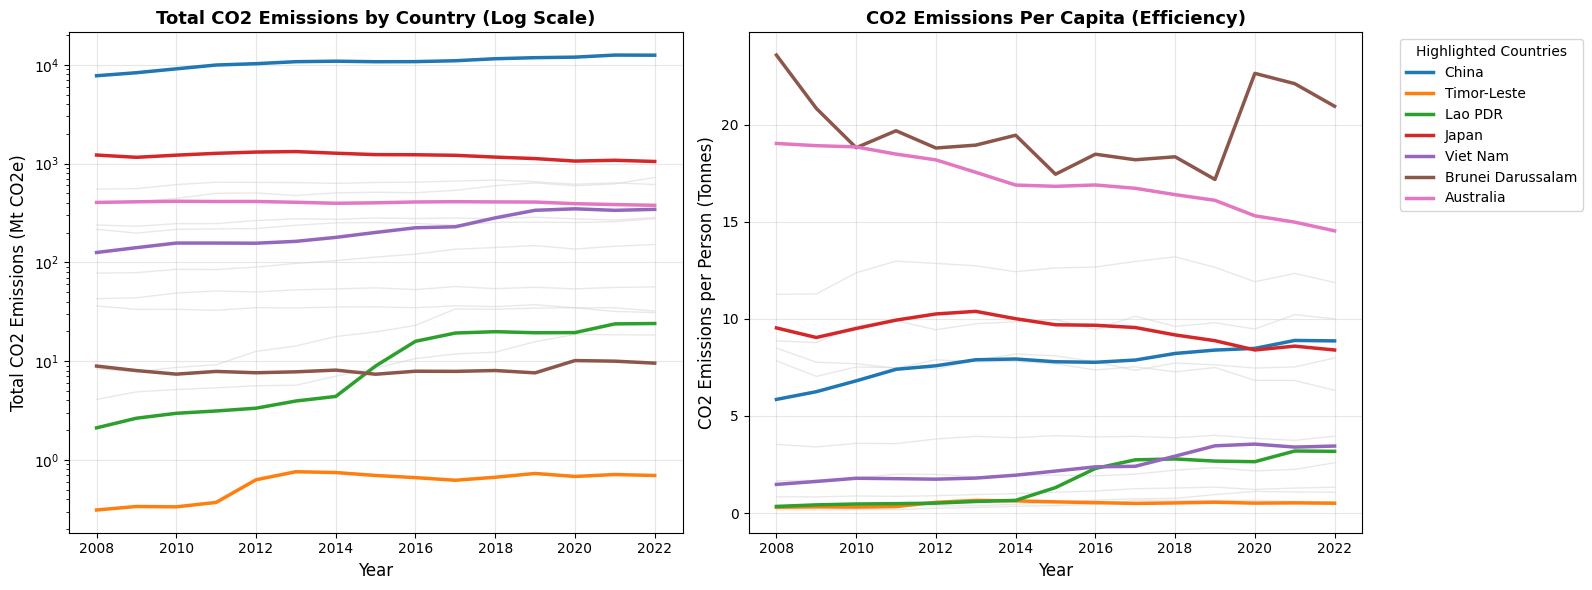

In [12]:
# Objective 6 Code

# Calculate CO2 emissions per capita (in Tonnes)
# Note: 1 Mt (Mega tonne) = 1,000,000 Tonnes
pivot_df['CO2 per capita (Tonnes)'] = (pivot_df['Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)'] * 1000000) / pivot_df['Population, total']

# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define key countries to highlight based on our analysis
highlight_countries = ['China', 'Timor-Leste', 'Lao PDR', 'Japan', 'Viet Nam', 'Brunei Darussalam', 'Australia']
palette = sns.color_palette("tab10", len(highlight_countries))

# --- Chart 1: Total CO2 Emissions (Log Scale) ---
# Plot background countries (light gray)
for country in pivot_df['Country Name'].unique():
    if country not in highlight_countries:
        country_data = pivot_df[pivot_df['Country Name'] == country]
        sns.lineplot(data=country_data, x='Year', y='Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)', 
                     color='lightgray', alpha=0.5, linewidth=1, ax=axes[0])

# Plot highlighted countries
for idx, country in enumerate(highlight_countries):
    country_data = pivot_df[pivot_df['Country Name'] == country]
    sns.lineplot(data=country_data, x='Year', y='Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)', 
                 color=palette[idx], linewidth=2.5, ax=axes[0])

axes[0].set_yscale('log') 
axes[0].set_title('Total CO2 Emissions by Country (Log Scale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Total CO2 Emissions (Mt CO2e)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# --- Chart 2: CO2 Emissions Per Capita ---
# Plot background countries (light gray)
for country in pivot_df['Country Name'].unique():
    if country not in highlight_countries:
        country_data = pivot_df[pivot_df['Country Name'] == country]
        sns.lineplot(data=country_data, x='Year', y='CO2 per capita (Tonnes)', 
                     color='lightgray', alpha=0.5, linewidth=1, ax=axes[1])

# Plot highlighted countries
for idx, country in enumerate(highlight_countries):
    country_data = pivot_df[pivot_df['Country Name'] == country]
    sns.lineplot(data=country_data, x='Year', y='CO2 per capita (Tonnes)', 
                 color=palette[idx], label=country, linewidth=2.5, ax=axes[1])

axes[1].set_title('CO2 Emissions Per Capita (Efficiency)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('CO2 Emissions per Person (Tonnes)', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Place the legend outside the second chart
axes[1].legend(title='Highlighted Countries', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Analysis & Conclusion (Objective 6)

* **Total Emissions (Log Scale):** Total emissions generally increased across the region. China is the dominant emitter (exceeding 10,000 Mt), while Timor-Leste remains the lowest (under 1 Mt). Lao PDR displays the steepest growth trajectory, particularly after 2014. Japan's emissions remained stable at roughly 1,200 Mt. Viet Nam experienced continuous growth, rising from approximately 100 Mt to near 400 Mt.
* **Per Capita Efficiency:** Viewing the data relative to population reveals a different dynamic. Brunei Darussalam has the highest per capita emissions, fluctuating between 18 and 23 tonnes per person. Australia ranks second but shows a notable decline from 19 to 15 tonnes per person. China's per capita emissions (rising from 6 to 9 tonnes) remain lower than several smaller nations. Timor-Leste maintains the smallest per capita footprint (under 1 tonne per person).

### Theme 3: Human Capital and Educational Investment

**Objective 7: Evaluate government priority for education**
*   **Chart Choice:** Horizontal Bar Chart. Most effective for ranking categorical data (countries) based on a single numerical value (average expenditure). Sorting the bars makes the comparison instantly readable.

C:\Users\tinti\AppData\Local\Temp\ipykernel_13564\2765238639.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_expenditure.values, y=edu_expenditure.index, palette='crest')


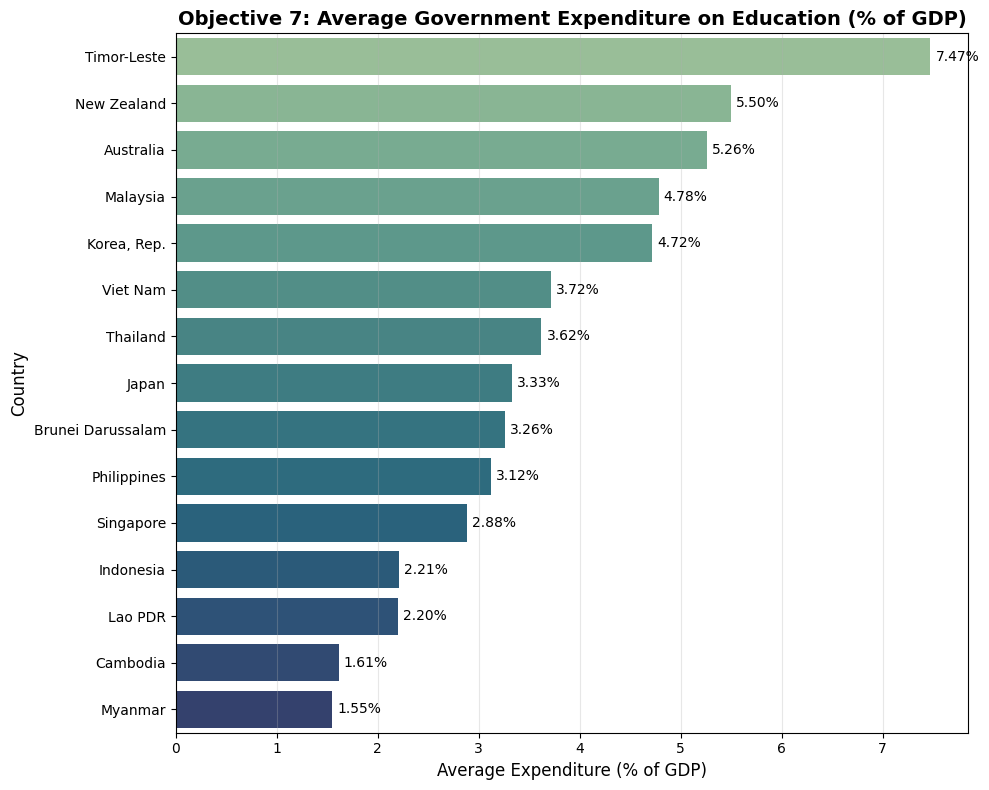

In [13]:
# Objective 7 Code
plt.figure(figsize=(10, 8))

# Calculate average education expenditure per country over the available years
edu_expenditure = pivot_df.groupby('Country Name')['Government expenditure on education, total (% of GDP)'].mean().sort_values(ascending=False)

# Drop countries with entirely NaN values for this metric to clean up the chart
edu_expenditure = edu_expenditure.dropna()

sns.barplot(x=edu_expenditure.values, y=edu_expenditure.index, palette='crest')

plt.title('Objective 7: Average Government Expenditure on Education (% of GDP)', fontsize=14, fontweight='bold')
plt.xlabel('Average Expenditure (% of GDP)', fontsize=12)
plt.ylabel('Country', fontsize=12)

# Add value labels to the end of the bars
for index, value in enumerate(edu_expenditure.values):
    plt.text(value + 0.05, index, f'{value:.2f}%', va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 7):**
* **Top Spender (Timor-Leste):** Timor-Leste spends the most on education, averaging 7.47% of its GDP over the period.
* **High Spenders (New Zealand & Australia):** New Zealand and Australia follow, both spending over 5% of their GDP on education (5.50% and 5.26%).
* **Middle Group:** The majority of the countries, including Viet Nam, Thailand, and Japan, spend between 3% and 4.7% of their GDP on education.
* **Lowest Spenders (Myanmar & Cambodia):** Myanmar (1.55%) and Cambodia (1.61%) spend the least on education. The gap between the highest and lowest spending countries is very wide (nearly 6%).

---

**Objective 8: Examine education investment and tertiary enrollment**
* **Chart Choice:** Scatter plot. Effectively maps the linear relationship between financial input (X-axis) and educational output (Y-axis) across numerical data points to see if higher spending leads to higher enrollment.

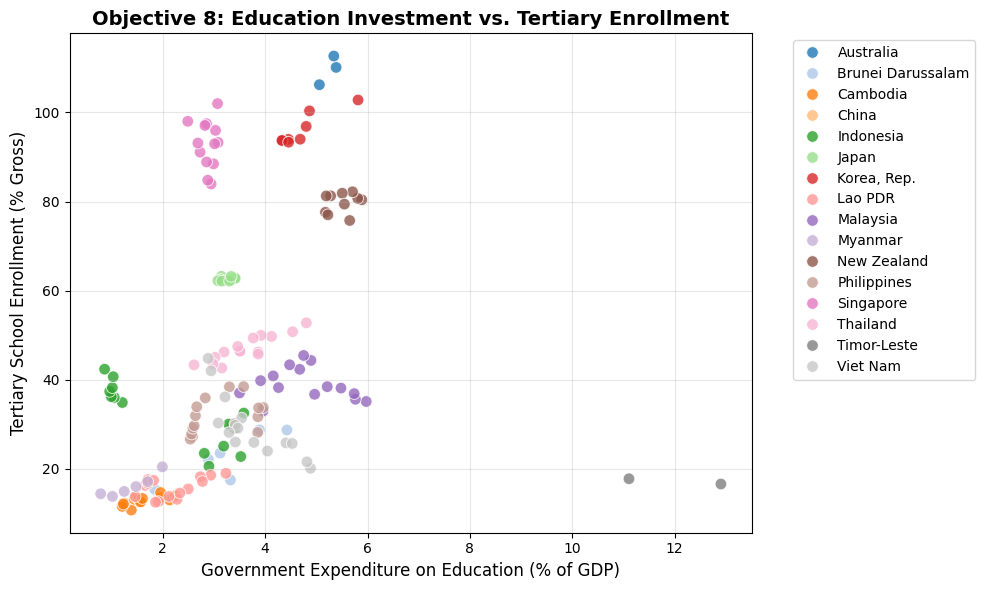

In [14]:
# Objective 8 Code
plt.figure(figsize=(10, 6))

sns.scatterplot(data=pivot_df, 
                x='Government expenditure on education, total (% of GDP)', 
                y='School enrollment, tertiary (% gross)', 
                hue='Country Name', 
                palette='tab20', s=70, alpha=0.8)

plt.title('Objective 8: Education Investment vs. Tertiary Enrollment', fontsize=14, fontweight='bold')
plt.xlabel('Government Expenditure on Education (% of GDP)', fontsize=12)
plt.ylabel('Tertiary School Enrollment (% Gross)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 8):**
* **No Strict Correlation:** Higher spending does not automatically guarantee higher enrollment. For example, Timor-Leste spends the most (% of GDP) but has very low tertiary enrollment.
* **High Efficiency:** Countries like South Korea (Korea, Rep.) and Australia achieve massive tertiary enrollment (near or above 100%) with moderate expenditure (around 4-5.5% of GDP).
* **Low Input, Low Output:** Countries like Cambodia and Myanmar cluster at the bottom left, showing that very low government investment aligns with very low tertiary enrollment.

---

**Objective 9: Monitor expansion of tertiary education access**
* **Chart Choice:** Line chart. Ideal for comparing multi-year growth trajectories for time-series data across categorical entities (nations). We will highlight specific nations with notable trajectories.

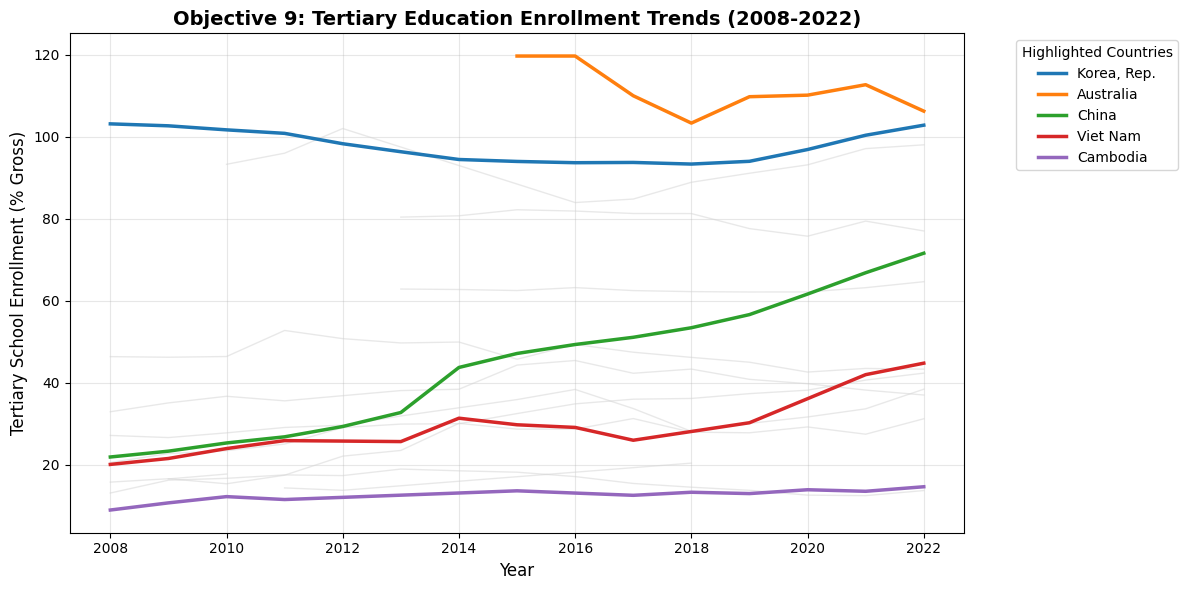

In [15]:
# Objective 9 Code
plt.figure(figsize=(12, 6))

# Highlight countries with interesting trends
highlight_edu = ['Korea, Rep.', 'Australia', 'China', 'Viet Nam', 'Cambodia']
palette_edu = sns.color_palette("tab10", len(highlight_edu))

# Plot background
for country in pivot_df['Country Name'].unique():
    if country not in highlight_edu:
        country_data = pivot_df[pivot_df['Country Name'] == country]
        sns.lineplot(data=country_data, x='Year', y='School enrollment, tertiary (% gross)', 
                     color='lightgray', alpha=0.5, linewidth=1)

# Plot highlights
for idx, country in enumerate(highlight_edu):
    country_data = pivot_df[pivot_df['Country Name'] == country]
    sns.lineplot(data=country_data, x='Year', y='School enrollment, tertiary (% gross)', 
                 color=palette_edu[idx], label=country, linewidth=2.5)

plt.title('Objective 9: Tertiary Education Enrollment Trends (2008-2022)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Tertiary School Enrollment (% Gross)', fontsize=12)
plt.legend(title='Highlighted Countries', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 9):**
* **General Upward Trend:** Almost all countries show an increase in tertiary enrollment over the 15 years.
* **Rapid Expansion:** China shows the most aggressive growth, shooting up from roughly 20% in 2008 to over 70% by 2022.
* **Top Performers:** Australia and South Korea remain at the very top, consistently hovering near or above 100% enrollment.
* **Slow Growth:** Viet Nam and Cambodia show relatively slow growth, reaching only roughly 45% and 15% respectively by the end of the period.

### Theme 4: Infrastructure and Public Health

**Objective 10: Measure progress in rural electrification**
* **Chart Choice:** Line chart. Highlights infrastructural catch-up progress for continuous time-series data, specifically focusing on developing nations. Since many developed nations are already at 100%, this allows us to clearly see the infrastructural catch-up progress.

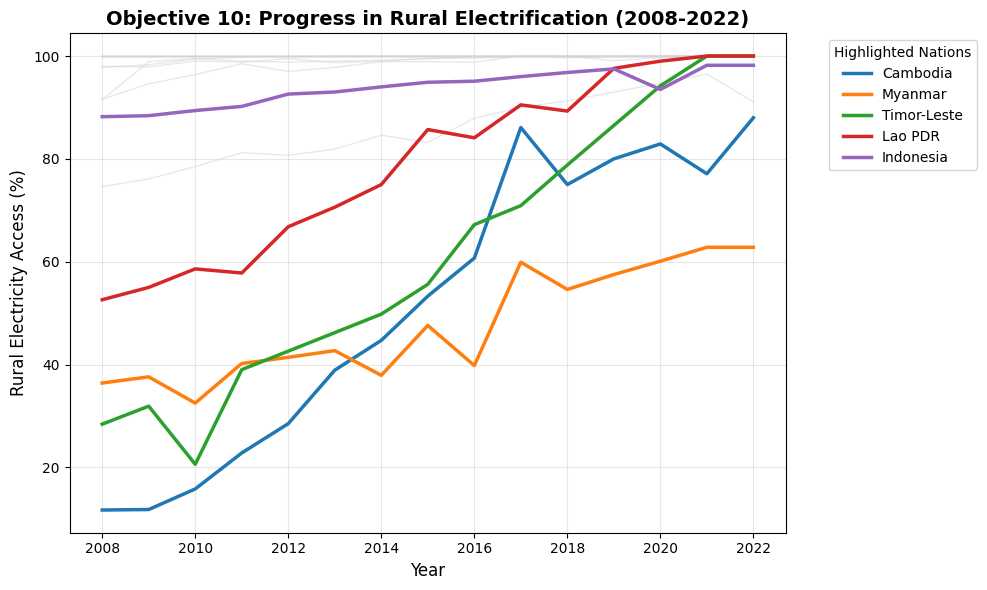

In [16]:
# Objective 10 Code
plt.figure(figsize=(10, 6))

# Highlight developing nations showing progress
highlight_elec = ['Cambodia', 'Myanmar', 'Timor-Leste', 'Lao PDR', 'Indonesia']
palette_elec = sns.color_palette("tab10", len(highlight_elec))

# Plot background
for country in pivot_df['Country Name'].unique():
    if country not in highlight_elec:
        country_data = pivot_df[pivot_df['Country Name'] == country]
        sns.lineplot(data=country_data, x='Year', y='Access to electricity, rural (% of rural population)', 
                     color='lightgray', alpha=0.5, linewidth=1)

# Plot highlights
for idx, country in enumerate(highlight_elec):
    country_data = pivot_df[pivot_df['Country Name'] == country]
    sns.lineplot(data=country_data, x='Year', y='Access to electricity, rural (% of rural population)', 
                 color=palette_elec[idx], label=country, linewidth=2.5)

plt.title('Objective 10: Progress in Rural Electrification (2008-2022)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Rural Electricity Access (%)', fontsize=12)
plt.legend(title='Highlighted Nations', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 10):**
* **The 100% Ceiling:** The gray lines show that most countries in the dataset already had 100% rural electricity access in 2008 and maintained it.
* **Massive Improvements:** Cambodia and Timor-Leste show incredible infrastructural growth. Cambodia grew from near 10% to nearly 90%, and Timor-Leste grew from roughly 30% to a full 100%.
* **Catch-up phase:** Lao PDR and Indonesia also rapidly closed the infrastructure gap (reaching 100%). Meanwhile, despite progress, Cambodia and Myanmar remain the lowest in the region.

---

**Objective 11: Evaluate water access and life expectancy relationship**
* **Chart Choice:** Scatter plot. Clearly reveals clusters and positive correlations between two continuous numerical variables in global public health data. This maps basic infrastructure (water) directly against human health outcomes (lifespan) to test for structural linkages.

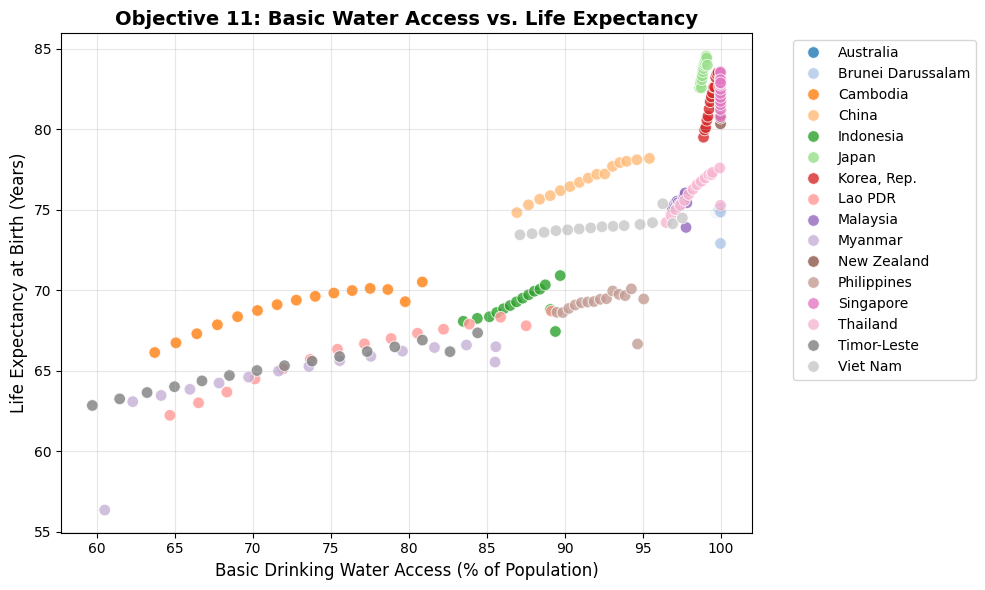

In [17]:
# Objective 11 Code
plt.figure(figsize=(10, 6))

sns.scatterplot(data=pivot_df, 
                x='People using at least basic drinking water services (% of population)', 
                y='Life expectancy at birth, total (years)', 
                hue='Country Name', 
                palette='tab20', s=70, alpha=0.8)

plt.title('Objective 11: Basic Water Access vs. Life Expectancy', fontsize=14, fontweight='bold')
plt.xlabel('Basic Drinking Water Access (% of Population)', fontsize=12)
plt.ylabel('Life Expectancy at Birth (Years)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 11):**
* **Strong Positive Cluster:** There is a clear, strong positive relationship. As drinking water access approaches 100%, life expectancy tightly clusters at higher ages (75 to 85 years).
* **Low Access, Low Lifespan:** Data points on the bottom left (mostly representing earlier years for countries like Timor-Leste, Myanmar, and Cambodia) show that lower water access (60-70%) strictly correlates with lower life expectancy (55-65 years). Notably, Myanmar consistently records the lowest outcomes on both metrics.

---

**Objective 12: Compare the distribution of life expectancy across countries**
*   **Chart Choice:** Violin plot. Ideal for comparing the probability distribution and central tendency (median/quartiles) of numerical data across multiple categories (countries). The violin plot, showing density curves, clearly illustrates exactly where the lifespan data clusters for each nation.

C:\Users\tinti\AppData\Local\Temp\ipykernel_13564\2296562129.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=pivot_df,


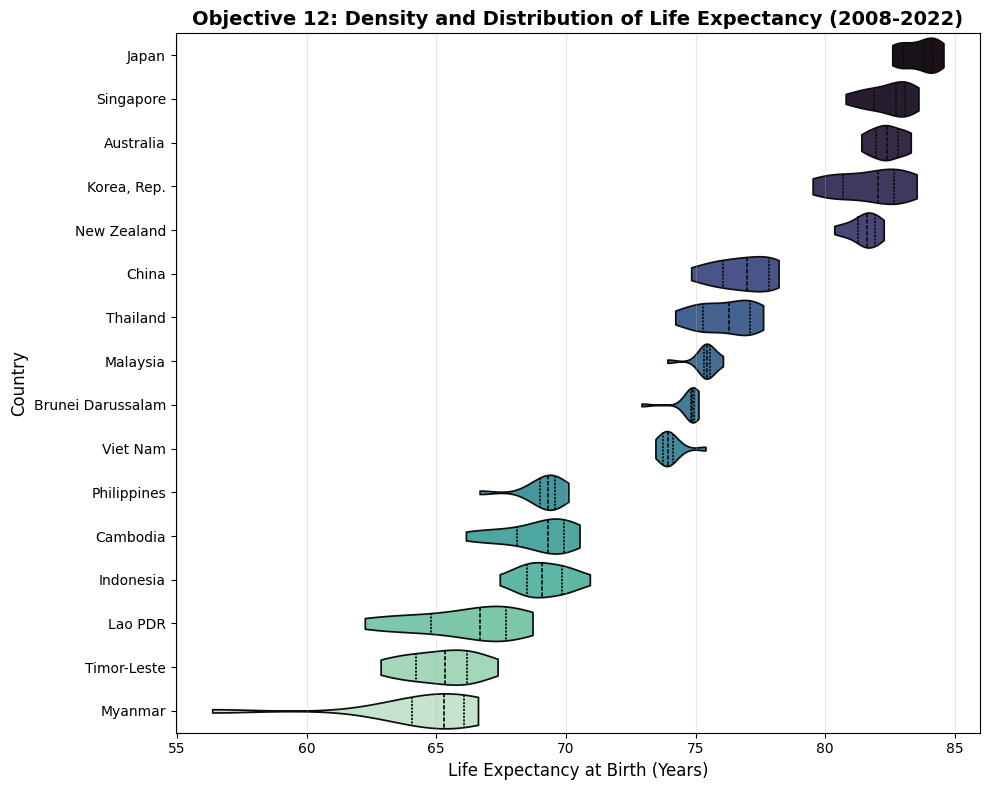

In [18]:
# Objective 12 Code
plt.figure(figsize=(10, 8))

# Calculate median life expectancy for sorting
median_life = pivot_df.groupby('Country Name')['Life expectancy at birth, total (years)'].median().sort_values(ascending=False)

# Violin plot instead of Box plot
sns.violinplot(data=pivot_df, 
            x='Life expectancy at birth, total (years)', 
            y='Country Name', 
            order=median_life.index,
            palette='mako', inner="quartile", cut=0)

plt.title('Objective 12: Density and Distribution of Life Expectancy (2008-2022)', fontsize=14, fontweight='bold')
plt.xlabel('Life Expectancy at Birth (Years)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 12):**
* **Strong Medical Disparity:** There is a significant, structural >20-year gap between top performers (Japan >83 years, Australia) and the vulnerable economies at the bottom (Myanmar and Timor-Leste around 64-67 years).
* **Significant Improvements & Broad Distribution (Bottom nations):** While Myanmar, Timor-Leste, and Cambodia sit at the bottom, their density curves are exceptionally long and stretched, indicating substantial upward progress in health outcomes over the 15-year period. (Notably, Myanmar's violin has a severe downward tail dropping near 56 years, reflecting the devastating human toll of Cyclone Nargis in 2008).
* **Structural Ceiling (Top nations):** Japan, Singapore, and Australia have "fat", short density bulges directly at the top. They have clearly hit a biological/medical ceiling around 83-84 years, exhibiting virtually zero variation and maintaining extreme stability over the entire period.

### Theme 5: Multi-Dimensional Synthesis

**Objective 13: Build a cross-indicator correlation overview**
* **Chart Choice:** Correlation heatmap. Provides a global view of pairwise correlation coefficients across all continuous numerical variables in a single matrix. **Red** indicates positive correlations, while **blue** indicates negative correlations

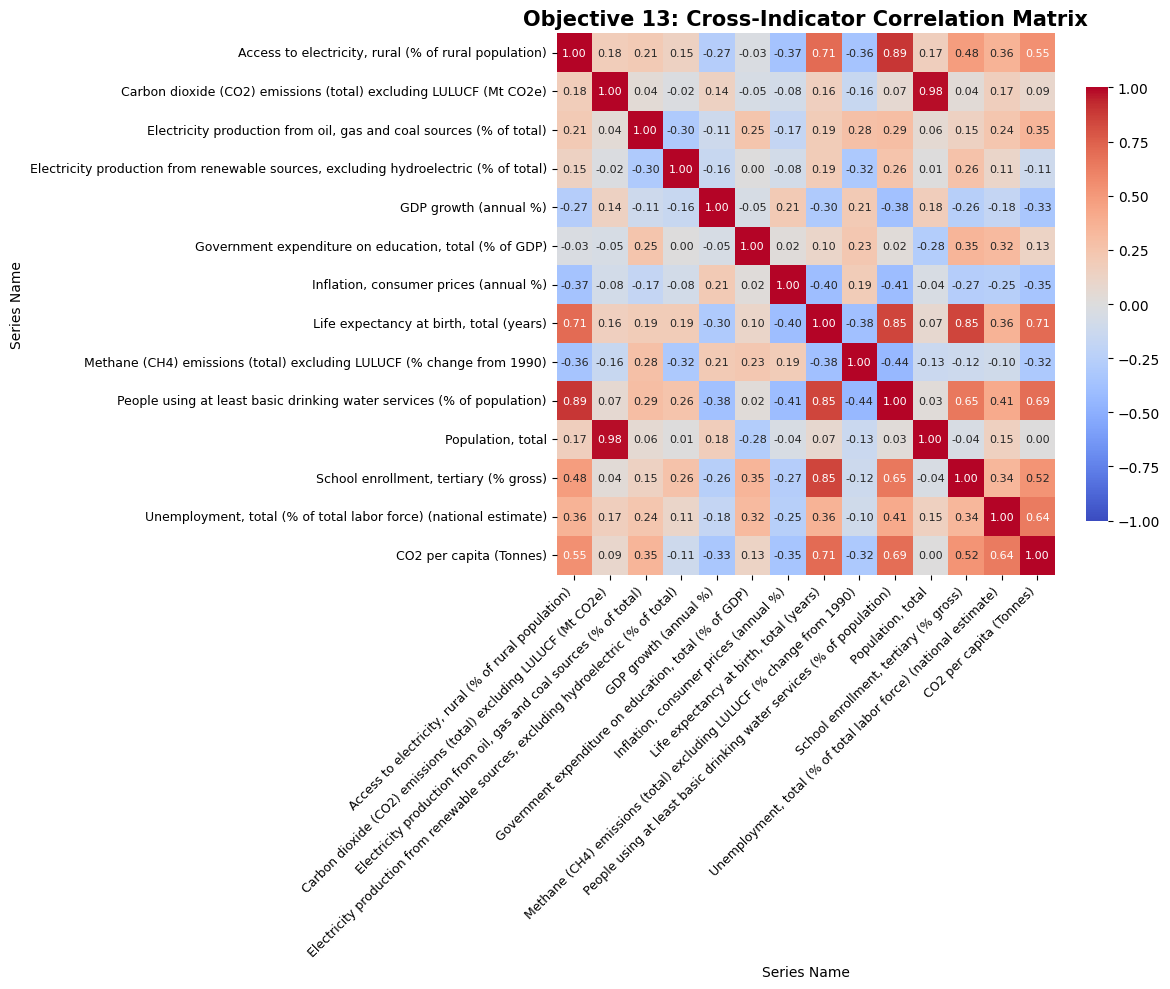

In [19]:
# Objective 13 Code
plt.figure(figsize=(12, 10))

# Select only numeric columns for correlation (excluding Year to focus on metrics)
numeric_df = pivot_df.drop(columns=['Country Name', 'Year']).select_dtypes(include=[np.number])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Create a clean heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, 
            annot_kws={"size": 8}, cbar_kws={'shrink': .8})

plt.title('Objective 13: Cross-Indicator Correlation Matrix', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 13):**
* **Strongest Positive Links:** "Life expectancy" and "Basic drinking water access" have an extremely strong positive correlation (0.85), confirming the findings in Objective 11. "Tertiary school enrollment" also strongly correlates with both life expectancy (0.85) and water access (0.65).
* **Negative Links:** "Inflation" has a notable negative correlation with both "Life expectancy" (-0.40) and "Water access" (-0.41). Additionally, "GDP growth" shows a weak negative correlation with "Water access" (-0.38), "Life expectancy" (-0.3) and "CO2 per capita" (-0.33), suggesting that rapid economic growth periods may not immediately lead to improved environmental efficiency or basic infrastructure distribution.
---

**Objective 14: Compare multi-dimensional country profiles**
*   **Chart Choice:** Radar chart (Spider chart). Perfect for synthesizing multi-dimensional numerical data into a profile to compare categorical entities (countries). We will map out 5 core development pillars for 4 representative nations.
*   **Design Choice:** To ensure that indicators with massively different units do not geometrically distort the shape, we must first collapse the measurements into country averages across the 15 years, and apply **Min-Max Scaling (0 to 1)** to normalize the axes. A perfectly balanced development footprint will resemble a large, uniform polygon.

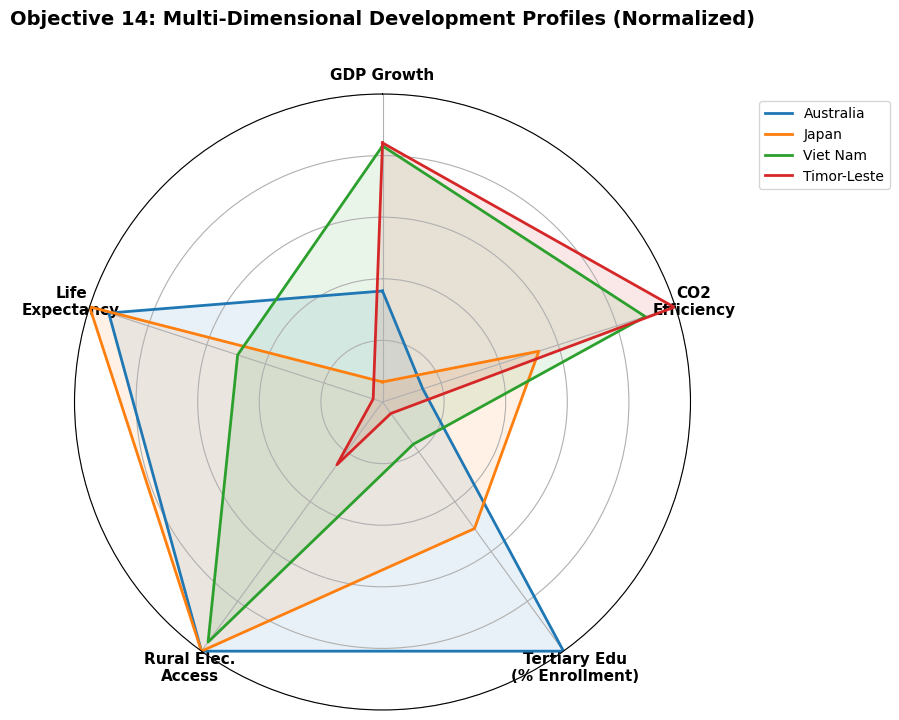

In [20]:
# Objective 14 Code
from sklearn.preprocessing import MinMaxScaler

# Select metrics for multi-dimensional profile
radar_metrics = [
    'GDP growth (annual %)', 
    'CO2 per capita (Tonnes)', 
    'School enrollment, tertiary (% gross)', 
    'Access to electricity, rural (% of rural population)', 
    'Life expectancy at birth, total (years)'
]

# Calculate averages for each country
avg_df = pivot_df.groupby('Country Name', as_index=False)[radar_metrics].mean()
avg_df = avg_df.dropna() # Just to be safe if any country dropped everything

# 1. Min-Max Scaling (0 to 1) for the Radar Chart
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(avg_df.iloc[:, 1:])

# Convert back to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=radar_metrics)

# FIX: Invert CO2 metric so further from center (1.0) means HIGH efficiency (Low CO2)
scaled_df['CO2 per capita (Tonnes)'] = 1 - scaled_df['CO2 per capita (Tonnes)']

scaled_df['Country Name'] = avg_df['Country Name'].values

# Define countries to contrast (e.g. Developed vs Emerging vs Vulnerable)
highlight_radar = ['Australia', 'Japan', 'Viet Nam', 'Timor-Leste']

# 2. Plotting the Radar Chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Create an angle for each metric axis
num_vars = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Complete the circle by appending the first angle to the end

# Clean up metric names for the chart labels (Changed to CO2 Efficiency)
short_labels = ['GDP Growth', 'CO2\nEfficiency', 'Tertiary Edu\n(% Enrollment)', 'Rural Elec.\nAccess', 'Life\nExpectancy']

colors = sns.color_palette("tab10", len(highlight_radar))

for idx, country in enumerate(highlight_radar):
    values = scaled_df[scaled_df['Country Name'] == country].iloc[0, :-1].tolist()
    values += values[:1]  # Close the polygon
    
    ax.plot(angles, values, color=colors[idx], linewidth=2, label=country)
    ax.fill(angles, values, color=colors[idx], alpha=0.1)

# Format the grid and labels
ax.set_theta_offset(np.pi / 2) # Top is 0 degrees
ax.set_theta_direction(-1) # Clockwise
ax.set_thetagrids(np.degrees(angles[:-1]), short_labels, fontsize=11, fontweight='bold')

ax.set_ylim(0, 1) # Normalised strictly between 0 and 1
ax.set_rgrids([0.2, 0.4, 0.6, 0.8, 1], angle=0, labels=[]) # Remove generic r-grid labels for a clean look

plt.title('Objective 14: Multi-Dimensional Development Profiles (Normalized)', size=14, fontweight='bold', y=1.1)
plt.legend(bbox_to_anchor=(1.1, 1), loc='upper left')
plt.show()

**Analysis & Conclusion (Objective 14):**
* **High Development, Low Efficiency (Australia):** Australia scores highly on Tertiary Education, Life Expectancy, and Rural Electrification. However, its polygon shrinks severely on CO2 Efficiency, highlighting a high per-capita environmental cost for its development.
* **Developed but Stagnant (Japan):** Japan exhibits a balanced, highly developed profile (maximized life expectancy and electrification, moderate CO2 efficiency) but shows significant weakness in GDP growth, reflecting economic stagnation.
* **Rapid Emerging Catch-up (Viet Nam):** Viet Nam displays strong GDP growth, high CO2 efficiency, and maximizes rural electrification. Its primary developmental lag remains in Tertiary Education, which forms the smallest point on its polygon.
* **Early Development Stage:** Timor-Leste has the most contracted overall profile. While it maximizes CO2 efficiency (due to negligible absolute emissions) and registers the highest peak volatility in GDP growth, it lags significantly behind the others in Education, Life Expectancy, and Rural Electrification compared to VietNam, with similar GDP growth, ..etc but but much higher Edu, Life and Electric value.

**Objective 15: Explore the modernization trade-off (Quality of Life vs. Emissions)**
*   **Chart Choice:** Bubble chart. Extends a scatter plot by visualizing three numerical variables simultaneously (x, y, and size), enabling complex multi-variate comparisons. We map Life Expectancy against CO2 per capita, using Bubble Size to represent Total Population, capturing absolute global impact while maintaining individual efficiency on the independent axes.

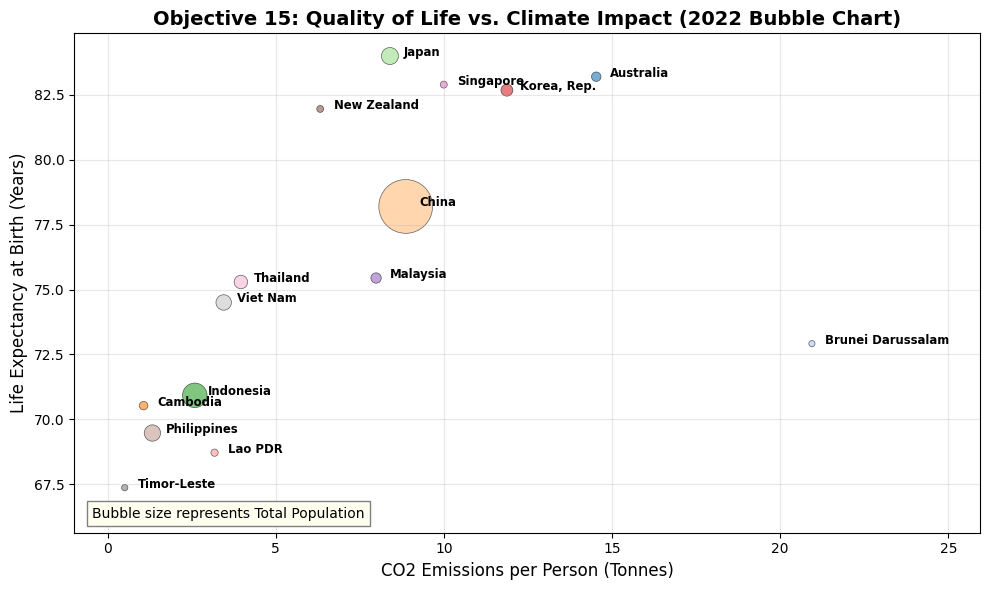

In [21]:
# Objective 15 Code
plt.figure(figsize=(10, 6))

if 'CO2 per capita (Tonnes)' not in pivot_df.columns:
    pivot_df['CO2 per capita (Tonnes)'] = (pivot_df['Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)'] * 1000000) / pivot_df['Population, total']

# Use 2022 subset for a clean Bubble chart
bubble_df = pivot_df[pivot_df['Year'] == 2022].copy()

# Ensure population is numeric for bubble size
population_sizes = bubble_df['Population, total'] / 1e6 # Size in millions for the visual scale

sns.scatterplot(data=bubble_df, 
                x='CO2 per capita (Tonnes)', 
                y='Life expectancy at birth, total (years)', 
                size=population_sizes, 
                sizes=(20, 1500), # Bubble size range
                hue='Country Name', 
                palette='tab20', alpha=0.6,
                legend=False, edgecolor='black', linewidth=0.5)

# Adding annotations to the bubbles for readability
for i in range(bubble_df.shape[0]):
    text_x = bubble_df['CO2 per capita (Tonnes)'].iloc[i] + 0.4
    text_y = bubble_df['Life expectancy at birth, total (years)'].iloc[i]
    if pd.notnull(text_x) and pd.notnull(text_y):
        plt.text(text_x, text_y, 
                bubble_df['Country Name'].iloc[i], 
                horizontalalignment='left', size='small', color='black', weight='semibold')

plt.title('Objective 15: Quality of Life vs. Climate Impact (2022 Bubble Chart)', fontsize=14, fontweight='bold')
plt.xlabel('CO2 Emissions per Person (Tonnes)', fontsize=12)
plt.ylabel('Life Expectancy at Birth (Years)', fontsize=12)

# Fix: Expand x-axis to prevent bubbles (like Brunei) from being cut off on the right
x_max = bubble_df['CO2 per capita (Tonnes)'].max() + 5
plt.xlim(left=-1, right=x_max)

# Information box
plt.text(x=0.02, y=0.03, s="Bubble size represents Total Population",
         transform=plt.gca().transAxes, fontsize=10,
         bbox=dict(facecolor='ivory', edgecolor='gray', pad=4.0))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 15):**
* **Health-Emission Trade-off:** A general positive correlation exists between carbon footprint and health outcomes. Nations with lower life expectancies (e.g., Cambodia, Lao PDR, Timor-Leste) cluster on the left with very low per-capita CO2 emissions (<5 tonnes). As life expectancy increases beyond 75 years, emissions per capita generally rise.
* **Population Impact (China):** The bubble size visualizes total population scale. China has a moderate per-capita footprint (~9 tonnes) compared to developed nations, but its massive population (largest bubble) translates this into the region's largest absolute global emission impact.
* **High-End Inefficiency (Australia & Brunei):** Environmental efficiency varies widely across high-emission models. Japan achieves the peak 84-year life expectancy at roughly 8 tonnes of CO2 per capita. In contrast, Australia generates nearly 15 tonnes per capita for a similar lifespan. Most strikingly, Brunei produces over 20 tonnes per capita while achieving a significantly lower health outcome (~73 years), highlighting heavily divergent and inefficient models of modernization.

---

## 5. References & Acknowledgments

### 5.1. References
* **Data Source:** World Bank Group (2024). *World Development Indicators (WDI)* - Asia Pacific territory (2008-2022 dataset).
* **Libraries:** `pandas` (McKinney, 2010), `matplotlib` (Hunter, 2007), `seaborn` (Waskom, 2021), `scikit-learn` (Pedregosa, 2011).

### 5.2. Acknowledgments
* **Instructor:** Sincere thanks to our instructor, Mr. **Vo Nhat Tan**, for guiding us through the Data Visualization course and providing valuable insights that enhanced our understanding.
* **AI Assistance:** This project's code structuring, data exploration, and debugging processes were greatly assisted by AI chatbots (**Google Gemini** via GitHub Copilot).